# Credit Card Fraud Detection Using Machine Learning

## Project Overview

This project uses machine learning to detect fraudulent credit card transactions.

The model classifies transactions into two categories:

- 0 → Normal Transaction
- 1 → Fraudulent Transaction

## 1. Project Objective

The main objective of this project is to develop a machine learning model that can identify fraudulent credit card transactions.

The project involves:

- Loading the credit card transaction dataset
- Cleaning and preprocessing the data
- Performing Exploratory Data Analysis (EDA)
- Scaling the transaction amount
- Splitting the data into training and testing sets
- Training a Logistic Regression model
- Making predictions
- Evaluating the model

## 2. Technologies Used

- Python
- Google Colab
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Joblib

## 3. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


## 4. Load Dataset

The credit card transaction dataset is loaded into a Pandas DataFrame for further analysis.

In [2]:
df = pd.read_csv('/content/creditcard.csv')

print("Dataset loaded successfully!")

Dataset loaded successfully!


## 5. Understanding the Dataset

The dataset contains credit card transaction information.

The important columns include:

- **Time** – The time elapsed between transactions.
- **V1 to V28** – Numerical features obtained from the original transaction data.
- **Amount** – The amount of money involved in the transaction.
- **Class** – The target variable used to identify fraud.

The `Class` column contains two values:

- **0** → Normal transaction
- **1** → Fraudulent transaction

We use the dataset information to understand its structure, size, columns, data types, and missing values before building the machine learning model.

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 35742
Number of columns: 31


In [5]:
print(df.columns)

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35742 entries, 0 to 35741
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    35742 non-null  int64  
 1   V1      35742 non-null  float64
 2   V2      35742 non-null  float64
 3   V3      35742 non-null  float64
 4   V4      35742 non-null  float64
 5   V5      35742 non-null  float64
 6   V6      35741 non-null  float64
 7   V7      35741 non-null  float64
 8   V8      35741 non-null  float64
 9   V9      35741 non-null  float64
 10  V10     35741 non-null  float64
 11  V11     35741 non-null  float64
 12  V12     35741 non-null  float64
 13  V13     35741 non-null  float64
 14  V14     35741 non-null  float64
 15  V15     35741 non-null  float64
 16  V16     35741 non-null  float64
 17  V17     35741 non-null  float64
 18  V18     35741 non-null  float64
 19  V19     35741 non-null  float64
 20  V20     35741 non-null  float64
 21  V21     35741 non-null  float64
 22

In [7]:
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        1
V7        1
V8        1
V9        1
V10       1
V11       1
V12       1
V13       1
V14       1
V15       1
V16       1
V17       1
V18       1
V19       1
V20       1
V21       1
V22       1
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64


## 6. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is used to understand the dataset and identify important patterns.

In this project, we analyze:

- The number of normal and fraudulent transactions.
- The distribution of transaction amounts.
- The difference in transaction amounts between normal and fraudulent transactions.
- The correlation between different features.

EDA helps us understand the data before training the machine learning model.

In [8]:
print(df['Class'].value_counts())

Class
0.0    35638
1.0      103
Name: count, dtype: int64


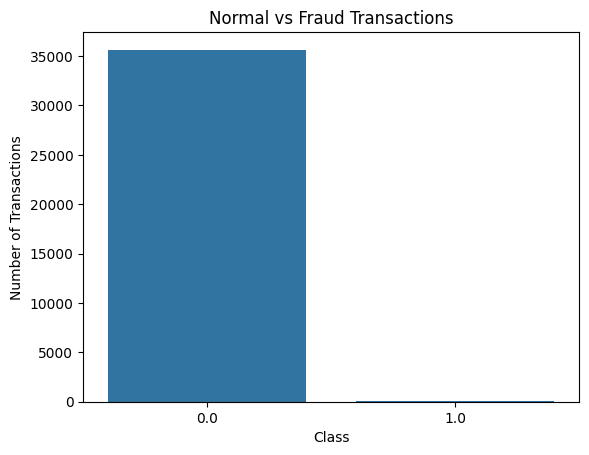

In [9]:
sns.countplot(x='Class', data=df)

plt.title('Normal vs Fraud Transactions')
plt.xlabel('Class')
plt.ylabel('Number of Transactions')

plt.show()

In [10]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,35742.000000,35742.000000,35742.000000,35742.000000,35742.000000,35742.000000,35741.000000,35741.000000,35741.000000,35741.000000,...,35741.000000,35741.000000,35741.000000,35741.000000,35741.000000,35741.000000,35741.000000,35741.000000,35741.000000,35741.000000
mean,23997.300823,-0.208427,0.072579,0.718292,0.195733,-0.216686,0.095575,-0.116847,0.032755,0.259459,...,-0.030876,-0.113555,-0.041571,0.007469,0.135958,0.021813,0.010836,0.003834,84.203356,0.002882
std,12423.654094,1.836736,1.540565,1.540896,1.409063,1.388746,1.310633,1.257788,1.242285,1.238161,...,0.769829,0.640398,0.545241,0.593343,0.435886,0.506559,0.388306,0.302016,227.279858,0.053606
min,0.000000,-30.552380,-40.978852,-31.103685,-5.172595,-42.147898,-23.496714,-26.548144,-41.484823,-7.175097,...,-20.262054,-8.593642,-26.751119,-2.836627,-7.495741,-1.438650,-8.567638,-9.617915,0.000000,0.000000
25%,12283.500000,-0.960139,-0.499301,0.244741,-0.714475,-0.818199,-0.644998,-0.598057,-0.155602,-0.523422,...,-0.239644,-0.536461,-0.178485,-0.326932,-0.127310,-0.331727,-0.063200,-0.007248,6.990000,0.000000
50%,28992.000000,-0.234480,0.114024,0.827554,0.188607,-0.255034,-0.163054,-0.073069,0.043456,0.135169,...,-0.081611,-0.087516,-0.051996,0.061818,0.175722,-0.063275,0.008848,0.021087,22.000000,0.000000
75%,34258.000000,1.162263,0.755015,1.456358,1.078531,0.302991,0.485169,0.436560,0.307599,0.991696,...,0.094995,0.296665,0.076214,0.398791,0.421085,0.301153,0.086772,0.076006,76.000000,0.000000
max,38241.000000,1.960497,16.713389,4.101716,13.143668,34.099309,22.529298,36.677268,20.007208,10.392889,...,22.614889,5.805795,13.876221,4.014444,5.525093,3.517346,11.135740,5.678671,7879.420000,1.000000


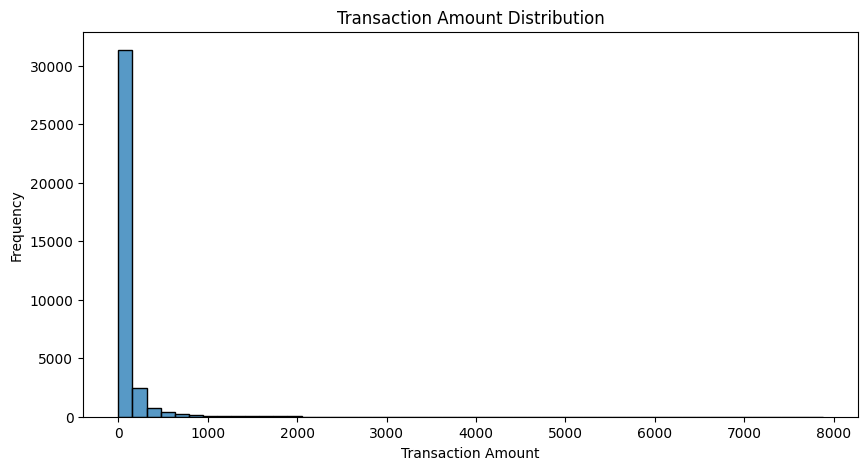

In [11]:
plt.figure(figsize=(10,5))

sns.histplot(df['Amount'], bins=50)

plt.title('Transaction Amount Distribution')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')

plt.show()

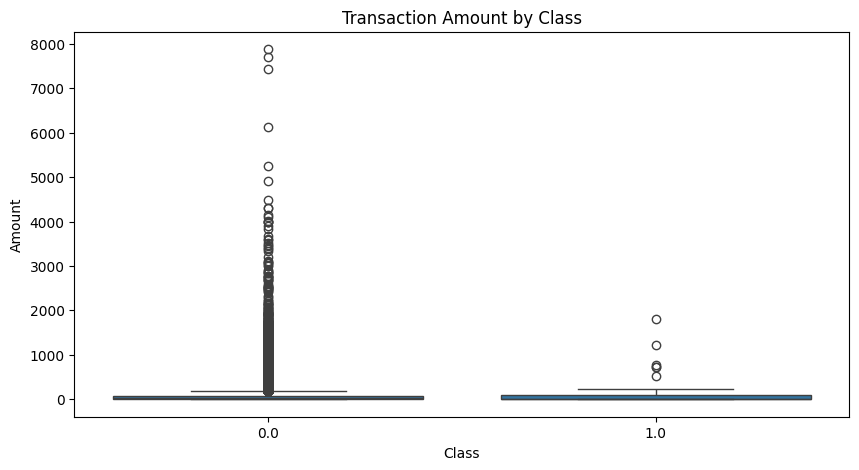

In [12]:
plt.figure(figsize=(10,5))

sns.boxplot(x='Class', y='Amount', data=df)

plt.title('Transaction Amount by Class')
plt.xlabel('Class')
plt.ylabel('Amount')

plt.show()

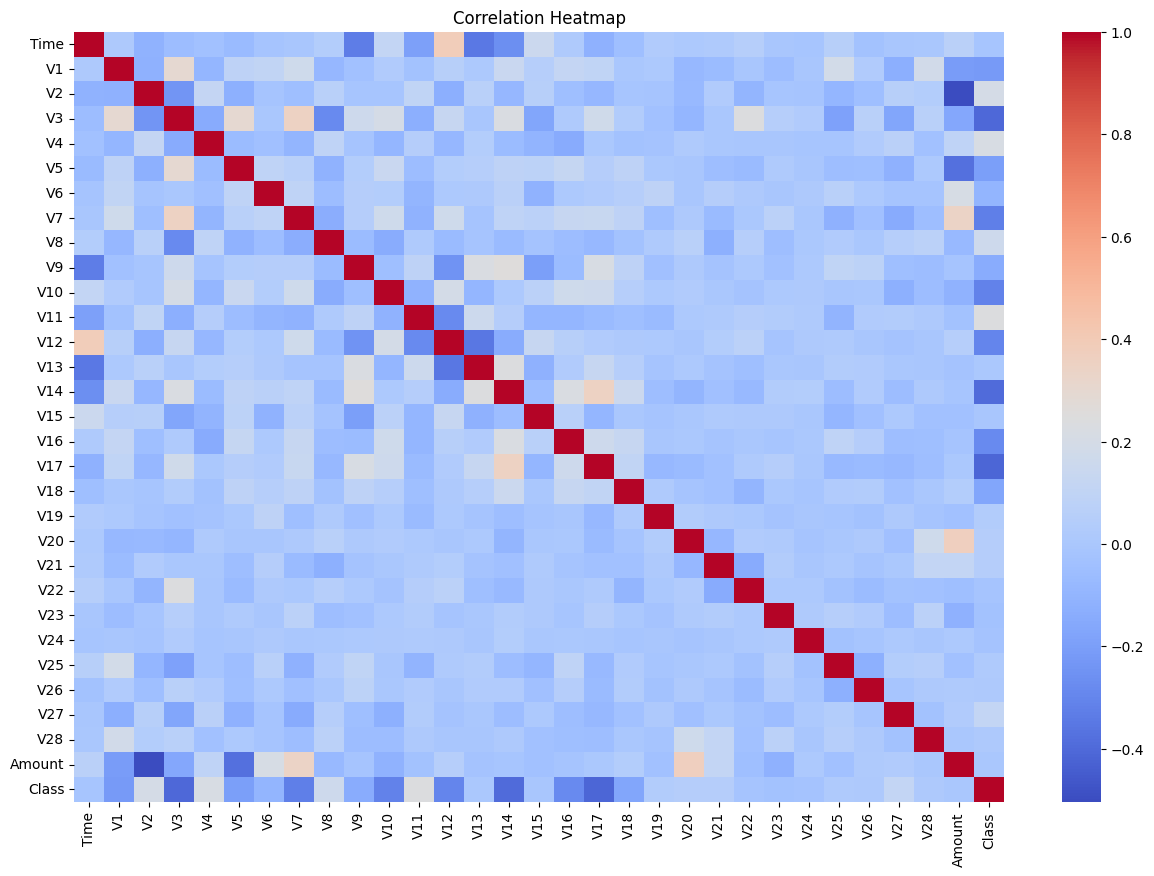

In [13]:
plt.figure(figsize=(15,10))

sns.heatmap(df.corr(), cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

## 7. Data Preprocessing

In [14]:
X = df.drop('Class', axis=1)
y = df['Class']

In [15]:
scaler = StandardScaler()

X['Amount'] = scaler.fit_transform(X[['Amount']])

In [16]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Data preprocessing completed successfully!")

Features shape: (35742, 30)
Target shape: (35742,)
Data preprocessing completed successfully!


## 8. Train-Test Split

The dataset is divided into two parts for machine learning.

- **80% of the data** is used for training the model.
- **20% of the data** is used for testing the model.

The training data is used to teach the machine learning model, while the testing data is used to evaluate its performance on unseen data.

The `stratify` parameter helps maintain the proportion of normal and fraudulent transactions in both the training and testing datasets.

In [28]:
# Remove rows where Class is missing
df = df.dropna(subset=['Class'])

# Create features and target again
X = df.drop('Class', axis=1)
y = df['Class']

# Scale the Amount column
scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])

# Split the dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("Data split successfully!")

Training data: (28592, 30)
Testing data: (7149, 30)
Data split successfully!


## 9. Model Training

Logistic Regression is used as the machine learning algorithm for this project.

The model learns patterns from the training data and uses these patterns to classify transactions as:

- **0 → Normal transaction**
- **1 → Fraudulent transaction**

The model is trained using the training features (`X_train`) and training labels (`y_train`).

In [31]:
# Create the Logistic Regression model

model = LogisticRegression(max_iter=5000)

# Train the model
model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


## 10. Predictions

After training the model, it is used to make predictions on the testing data.

The model predicts whether each transaction is:

- **0 → Normal transaction**
- **1 → Fraudulent transaction**

In [20]:
# Make predictions on the test data

y_pred = model.predict(X_test)

print("Predictions completed successfully!")

Predictions completed successfully!


## 11. Model Evaluation

The trained model is evaluated using four important performance metrics:

- **Accuracy** – Measures the overall percentage of correct predictions.
- **Precision** – Measures how many transactions predicted as fraud were actually fraudulent.
- **Recall** – Measures how many actual fraudulent transactions were detected.
- **F1 Score** – Provides a balance between precision and recall.

These metrics are especially important for fraud detection because detecting fraudulent transactions correctly is more important than accuracy alone.

In [21]:
# Calculate performance metrics

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Model Performance")
print("-------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Model Performance
-------------------------
Accuracy : 0.9974821653378095
Precision: 0.5714285714285714
Recall   : 0.5714285714285714
F1 Score : 0.5714285714285714


## 12. Confusion Matrix

A confusion matrix is used to understand how well the model classified normal and fraudulent transactions.

It shows four types of predictions:

- **True Negative (TN)** – Normal transactions correctly predicted as normal.
- **False Positive (FP)** – Normal transactions incorrectly predicted as fraud.
- **False Negative (FN)** – Fraudulent transactions incorrectly predicted as normal.
- **True Positive (TP)** – Fraudulent transactions correctly predicted as fraud.

In [22]:
# Create confusion matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[7119    9]
 [   9   12]]


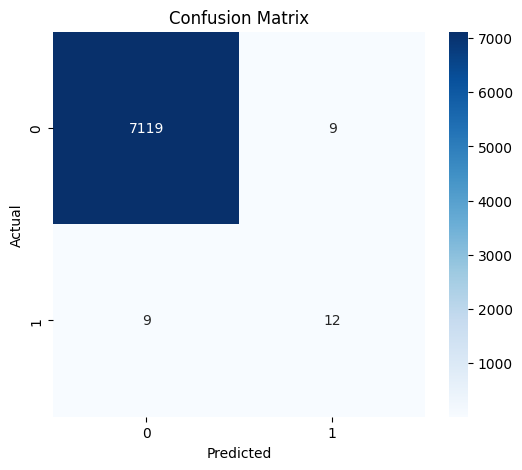

In [23]:
# Visualize confusion matrix

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

## 13. Classification Report

The classification report provides detailed performance measurements for each class.

It includes:

- **Precision**
- **Recall**
- **F1-score**
- **Support**

These metrics help evaluate how effectively the model detects both normal and fraudulent transactions.

In [24]:
print("Classification Report")
print("---------------------")

print(classification_report(y_test, y_pred))

Classification Report
---------------------
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      7128
         1.0       0.57      0.57      0.57        21

    accuracy                           1.00      7149
   macro avg       0.79      0.79      0.79      7149
weighted avg       1.00      1.00      1.00      7149



In [25]:
results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Score': [accuracy, precision, recall, f1]
})

results

,Metric,Score
0,Accuracy,0.997482
1,Precision,0.571429
2,Recall,0.571429
3,F1 Score,0.571429


## 14. Save Trained Model

The trained Logistic Regression model is saved as a `.pkl` file using Joblib.

Saving the model allows it to be reused later without training it again.

In [26]:
import joblib

joblib.dump(model, 'credit_card_fraud_model.pkl')

print("Model saved successfully!")

Model saved successfully!


In [27]:
joblib.dump(scaler, 'scaler.pkl')

print("Scaler saved successfully!")

Scaler saved successfully!


## 15. Conclusion

The Credit Card Fraud Detection project successfully uses machine learning to classify credit card transactions as normal or fraudulent.

The dataset was explored and preprocessed before training the Logistic Regression model. Exploratory Data Analysis was performed to understand transaction patterns, and the data was divided into training and testing sets.

The model was evaluated using accuracy, precision, recall, F1-score, confusion matrix, and classification report. Since the dataset contains many more normal transactions than fraudulent transactions, precision, recall, and F1-score are important measures for evaluating fraud detection performance.

The trained model and scaler were saved using Joblib so that they can be reused in the future.

This project demonstrates how machine learning can be applied to help detect potentially fraudulent credit card transactions.